In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)


## 2. Dataset



In [2]:
from pathlib import Path


DATA_PATH = "JAL_RAKSHAK_8000_Final_FilterHealth_WaterQuality_Dataset_60_40.csv"


DATA_PATH = str(Path(DATA_PATH).expanduser())

if not Path(DATA_PATH).exists():
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. Update DATA_PATH above to the full path "
        f"of your dataset file on this machine."
    )


In [3]:

if DATA_PATH.lower().endswith(".csv"):
    df = pd.read_csv(DATA_PATH)
else:
    df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (8000, 23)


,Sample_ID,Raw_TDS_ppm,Raw_Turbidity_NTU,Raw_Temperature_C,Treated_TDS_ppm,Treated_Turbidity_NTU,Treated_pH,Treated_Temperature_C,Flow_Rate_L_min,TDS_Removal_Efficiency_pct,...,Efficiency_Improvement_pp,Rolling_3Cycle_Avg_Efficiency_pct,Efficiency_Trend_pct,Previous_Turbidity_Efficiency_pct,Rolling_3Cycle_Avg_Turbidity_Efficiency_pct,Cycle_Number,Filter_Health_Score_pct,Water_Quality_Class,Filter_Health,ML_Split
0,JR-02216,510.68,1.23,23.77,49.69,0.16,6.98,23.86,1.719,90.27,...,4.62,86.69,5.39,80.35,83.13,11,99.67,SAFE,HEALTHY,TRAIN
1,JR-02583,549.70,5.40,27.79,98.93,0.11,7.33,27.65,1.261,82.00,...,5.60,82.67,7.33,90.72,95.57,12,98.73,SAFE,HEALTHY,TEST
2,JR-01663,441.20,5.75,24.64,55.75,1.31,7.00,23.36,1.822,87.36,...,0.37,86.61,0.43,87.68,80.89,6,94.37,SAFE,HEALTHY,TRAIN
3,JR-03028,298.81,2.09,19.60,16.06,0.26,7.25,19.76,2.000,94.63,...,-3.37,95.85,-3.44,81.53,87.26,19,100.00,SAFE,HEALTHY,TEST
4,JR-04344,424.17,9.61,23.27,97.90,2.59,7.74,22.89,1.480,76.92,...,1.28,76.98,1.69,72.58,74.80,24,84.40,WARNING,MODERATE,TRAIN


## 3. Basic Data Inspection

In [4]:
print("Columns:\n", list(df.columns))
print("\nData types:\n", df.dtypes)


Columns:
 ['Sample_ID', 'Raw_TDS_ppm', 'Raw_Turbidity_NTU', 'Raw_Temperature_C', 'Treated_TDS_ppm', 'Treated_Turbidity_NTU', 'Treated_pH', 'Treated_Temperature_C', 'Flow_Rate_L_min', 'TDS_Removal_Efficiency_pct', 'Turbidity_Removal_Efficiency_pct', 'Temperature_Difference_C', 'Previous_TDS_Efficiency_pct', 'Efficiency_Improvement_pp', 'Rolling_3Cycle_Avg_Efficiency_pct', 'Efficiency_Trend_pct', 'Previous_Turbidity_Efficiency_pct', 'Rolling_3Cycle_Avg_Turbidity_Efficiency_pct', 'Cycle_Number', 'Filter_Health_Score_pct', 'Water_Quality_Class', 'Filter_Health', 'ML_Split']

Data types:
 Sample_ID                                          str
Raw_TDS_ppm                                    float64
Raw_Turbidity_NTU                              float64
Raw_Temperature_C                              float64
Treated_TDS_ppm                                float64
Treated_Turbidity_NTU                          float64
Treated_pH                                     float64
Treated_Temperature_C   

In [5]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [6]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")
if n_dupes > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates dropped. New shape:", df.shape)


Duplicate rows: 0


In [7]:
# Class distribution checks
print("Filter_Health distribution:")
print(df["Filter_Health"].value_counts(normalize=True).round(3) * 100)

print("\nWater_Quality_Class distribution:")
print(df["Water_Quality_Class"].value_counts(normalize=True).round(3) * 100)

print("\nML_Split distribution:")
print(df["ML_Split"].value_counts())


Filter_Health distribution:
Filter_Health
HEALTHY      50.0
MODERATE     30.0
UNHEALTHY    20.0
Name: proportion, dtype: float64

Water_Quality_Class distribution:
Water_Quality_Class
SAFE        50.0
WARNING     30.0
CRITICAL    20.0
Name: proportion, dtype: float64

ML_Split distribution:
ML_Split
TRAIN    4800
TEST     3200
Name: count, dtype: int64


## 4. Feature Definitions


In [8]:
# ---- Columns that must NEVER be used as ML features ----
NEVER_FEATURES = ["Sample_ID", "Water_Quality_Class", "Filter_Health", "ML_Split"]

# ---- MODEL 1: Filter Health Prediction ----
FILTER_HEALTH_TARGET = "Filter_Health"

FILTER_HEALTH_FEATURES = [
    "Raw_TDS_ppm", "Raw_Turbidity_NTU", "Raw_Temperature_C",
    "Treated_TDS_ppm", "Treated_Turbidity_NTU", "Treated_pH", "Treated_Temperature_C",
    "Flow_Rate_L_min",
    "TDS_Removal_Efficiency_pct", "Turbidity_Removal_Efficiency_pct", "Temperature_Difference_C",
    "Previous_TDS_Efficiency_pct", "Efficiency_Improvement_pp",
    "Rolling_3Cycle_Avg_Efficiency_pct", "Efficiency_Trend_pct",
    "Previous_Turbidity_Efficiency_pct", "Rolling_3Cycle_Avg_Turbidity_Efficiency_pct",
    "Cycle_Number",
]
assert len(FILTER_HEALTH_FEATURES) == 18, "Filter Health feature list must contain exactly 18 features"
assert "Filter_Health_Score_pct" not in FILTER_HEALTH_FEATURES, "LEAKAGE: engineering score must not be a feature"

# ---- MODEL 2: Water Quality Classification ----
WATER_QUALITY_TARGET = "Water_Quality_Class"

WATER_QUALITY_FEATURES = [
    "Raw_TDS_ppm", "Raw_Turbidity_NTU", "Raw_Temperature_C",
    "Treated_TDS_ppm", "Treated_Turbidity_NTU", "Treated_pH", "Treated_Temperature_C",
    "TDS_Removal_Efficiency_pct", "Turbidity_Removal_Efficiency_pct", "Temperature_Difference_C",
]

# Sanity checks: none of the forbidden columns are in either feature list
for feat in FILTER_HEALTH_FEATURES + WATER_QUALITY_FEATURES:
    assert feat not in NEVER_FEATURES, f"Forbidden feature found: {feat}"
    assert feat != "Filter_Health_Score_pct", "Engineering score leaked into features"

print("Filter Health features (n=%d):" % len(FILTER_HEALTH_FEATURES))
print(FILTER_HEALTH_FEATURES)
print("\nWater Quality features (n=%d):" % len(WATER_QUALITY_FEATURES))
print(WATER_QUALITY_FEATURES)


Filter Health features (n=18):
['Raw_TDS_ppm', 'Raw_Turbidity_NTU', 'Raw_Temperature_C', 'Treated_TDS_ppm', 'Treated_Turbidity_NTU', 'Treated_pH', 'Treated_Temperature_C', 'Flow_Rate_L_min', 'TDS_Removal_Efficiency_pct', 'Turbidity_Removal_Efficiency_pct', 'Temperature_Difference_C', 'Previous_TDS_Efficiency_pct', 'Efficiency_Improvement_pp', 'Rolling_3Cycle_Avg_Efficiency_pct', 'Efficiency_Trend_pct', 'Previous_Turbidity_Efficiency_pct', 'Rolling_3Cycle_Avg_Turbidity_Efficiency_pct', 'Cycle_Number']

Water Quality features (n=10):
['Raw_TDS_ppm', 'Raw_Turbidity_NTU', 'Raw_Temperature_C', 'Treated_TDS_ppm', 'Treated_Turbidity_NTU', 'Treated_pH', 'Treated_Temperature_C', 'TDS_Removal_Efficiency_pct', 'Turbidity_Removal_Efficiency_pct', 'Temperature_Difference_C']


## 5. Train / Test Split (using the `ML_Split` column)



In [10]:
train_df = df[df["ML_Split"].str.upper() == "TRAIN"].reset_index(drop=True)
test_df  = df[df["ML_Split"].str.upper() == "TEST"].reset_index(drop=True)

print(f"TRAIN rows: {len(train_df)}  |  TEST rows: {len(test_df)}")
print(f"TRAIN %: {len(train_df)/len(df)*100:.1f}%  |  TEST %: {len(test_df)/len(df)*100:.1f}%")


TRAIN rows: 4800  |  TEST rows: 3200
TRAIN %: 60.0%  |  TEST %: 40.0%


## 6. Reusable Training & Evaluation Function



In [11]:
def train_and_evaluate(train_df, test_df, feature_cols, target_col, task_name):
    """
    Trains RandomForest, XGBoost and CatBoost on (feature_cols -> target_col)
    using the pre-defined TRAIN/TEST split, and returns a results dictionary.
    """
    X_train = train_df[feature_cols].copy()
    y_train_raw = train_df[target_col].copy()
    X_test = test_df[feature_cols].copy()
    y_test_raw = test_df[target_col].copy()

    # Encode string labels -> integers (fit only on TRAIN to avoid leakage of label info)
    le = LabelEncoder()
    y_train = le.fit_transform(y_train_raw)
    y_test = le.transform(y_test_raw)
    class_names = list(le.classes_)

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            objective="multi:softprob", num_class=len(class_names),
            eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=300, learning_rate=0.1, depth=6,
            loss_function="MultiClass", random_state=RANDOM_STATE,
            verbose=False
        ),
    }

    results = {}
    print(f"\n{'='*70}\nTASK: {task_name}\n{'='*70}")

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred = np.array(y_pred).ravel()  # flatten (CatBoost/XGB can return column vectors)

        acc = accuracy_score(y_test, y_pred)
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )
        prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
            y_test, y_pred, average="weighted", zero_division=0
        )
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(
            y_test, y_pred, target_names=class_names, zero_division=0
        )

        # Feature importance (handles the API differences between the three libraries)
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        else:
            importances = np.zeros(len(feature_cols))
        feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

        results[name] = {
            "model": model,
            "accuracy": acc,
            "precision_macro": prec_macro, "recall_macro": rec_macro, "f1_macro": f1_macro,
            "precision_weighted": prec_weighted, "recall_weighted": rec_weighted, "f1_weighted": f1_weighted,
            "confusion_matrix": cm,
            "classification_report": report,
            "feature_importance": feat_importance,
        }

        print(f"\n--- {name} ---")
        print(f"Accuracy: {acc:.4f}  |  Macro F1: {f1_macro:.4f}  |  Weighted F1: {f1_weighted:.4f}")
        print(report)

        # Warn if suspiciously perfect (possible leakage / overly-separable synthetic data)
        if acc >= 0.995:
            print(f"[CHECK] {name} accuracy is >=99.5% — verify there is no leakage; "
                  f"this can also happen with cleanly-separable synthetic data.")

    return {
        "task_name": task_name,
        "label_encoder": le,
        "class_names": class_names,
        "feature_cols": feature_cols,
        "results": results,
        "X_test": X_test,
        "y_test": y_test,
    }


## 7. Helper: Comparison Table, Confusion Matrices & Feature Importance Plots

In [12]:
def build_comparison_table(task_output):
    rows = []
    for name, r in task_output["results"].items():
        rows.append({
            "Model": name,
            "Accuracy": round(r["accuracy"], 4),
            "Precision (macro)": round(r["precision_macro"], 4),
            "Recall (macro)": round(r["recall_macro"], 4),
            "F1 (macro)": round(r["f1_macro"], 4),
            "Precision (weighted)": round(r["precision_weighted"], 4),
            "Recall (weighted)": round(r["recall_weighted"], 4),
            "F1 (weighted)": round(r["f1_weighted"], 4),
        })
    return pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)


def plot_confusion_matrices(task_output):
    class_names = task_output["class_names"]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, r) in zip(axes, task_output["results"].items()):
        sns.heatmap(r["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
        ax.set_title(f"{name}\n(Acc={r['accuracy']:.3f}, Macro F1={r['f1_macro']:.3f})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    plt.suptitle(f"Confusion Matrices — {task_output['task_name']}", y=1.05, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(task_output, model_name, top_n=None):
    r = task_output["results"][model_name]
    fi = r["feature_importance"]
    if top_n:
        fi = fi.head(top_n)
    plt.figure(figsize=(8, max(4, 0.35 * len(fi))))
    sns.barplot(x=fi.values, y=fi.index, color="#2b7a78")
    plt.title(f"Feature Importance — {model_name} ({task_output['task_name']})")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def select_best_model(task_output):
    """Best model = highest Macro F1 (primary metric, robust to class imbalance)."""
    best_name = max(task_output["results"], key=lambda n: task_output["results"][n]["f1_macro"])
    return best_name, task_output["results"][best_name]


## 8. Train — Filter Health Prediction

In [13]:
filter_health_output = train_and_evaluate(
    train_df, test_df,
    feature_cols=FILTER_HEALTH_FEATURES,
    target_col=FILTER_HEALTH_TARGET,
    task_name="Filter Health Prediction",
)

fh_comparison_table = build_comparison_table(filter_health_output)
print("\nFilter Health — Model Comparison Table:")
fh_comparison_table



TASK: Filter Health Prediction

--- Random Forest ---
Accuracy: 0.9313  |  Macro F1: 0.9252  |  Weighted F1: 0.9310
              precision    recall  f1-score   support

     HEALTHY       0.95      0.97      0.96      1600
    MODERATE       0.90      0.87      0.88       960
   UNHEALTHY       0.94      0.93      0.93       640

    accuracy                           0.93      3200
   macro avg       0.93      0.92      0.93      3200
weighted avg       0.93      0.93      0.93      3200


--- XGBoost ---
Accuracy: 0.9272  |  Macro F1: 0.9213  |  Weighted F1: 0.9266
              precision    recall  f1-score   support

     HEALTHY       0.94      0.97      0.95      1600
    MODERATE       0.90      0.86      0.88       960
   UNHEALTHY       0.93      0.93      0.93       640

    accuracy                           0.93      3200
   macro avg       0.92      0.92      0.92      3200
weighted avg       0.93      0.93      0.93      3200


--- CatBoost ---
Accuracy: 0.9372  |  Mac

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
0,CatBoost,0.9372,0.9349,0.9292,0.9318,0.9367,0.9372,0.9367
1,Random Forest,0.9313,0.9273,0.9232,0.9252,0.9308,0.9313,0.9310
2,XGBoost,0.9272,0.9239,0.9190,0.9213,0.9266,0.9272,0.9266


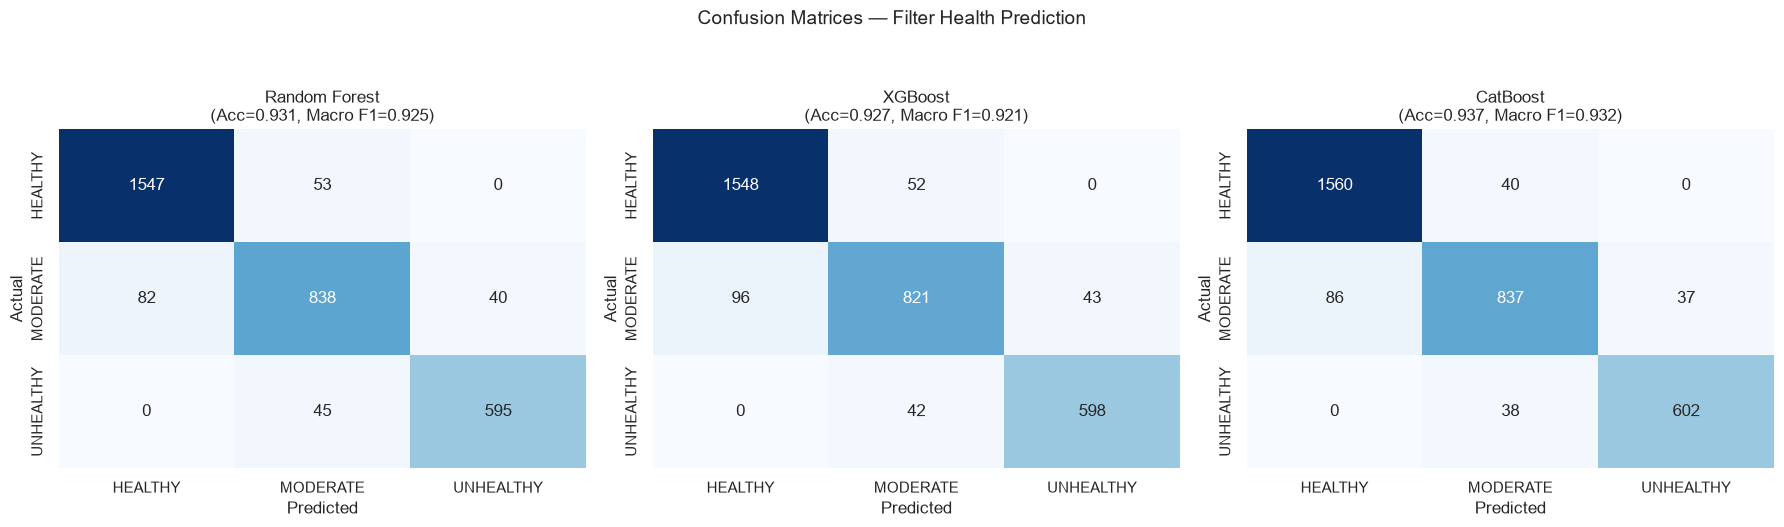

In [14]:
plot_confusion_matrices(filter_health_output)


Best Filter Health model (by Macro F1): CatBoost


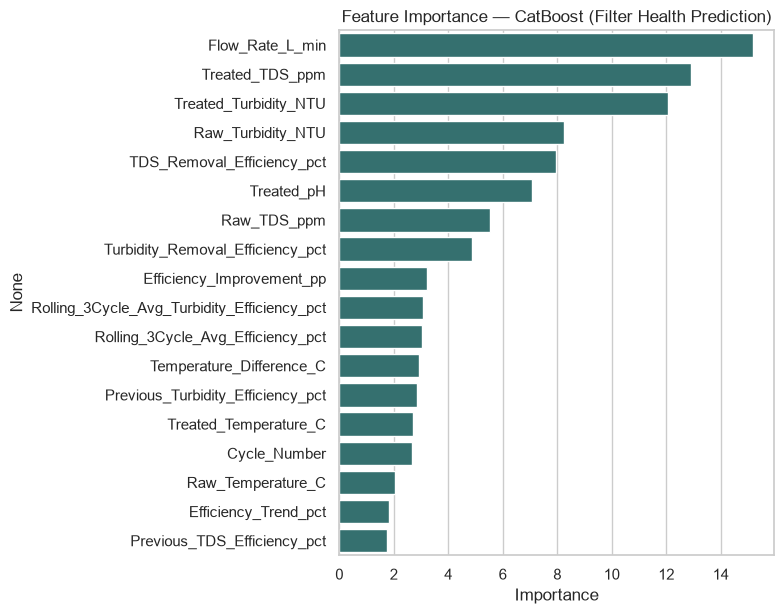

In [16]:
fh_best_name, fh_best = select_best_model(filter_health_output)
print(f"Best Filter Health model (by Macro F1): {fh_best_name}")
plot_feature_importance(filter_health_output, fh_best_name)


In [17]:
# Feature importance specifically for the features the requirements doc asked us to watch closely
watch_features = [
    "Flow_Rate_L_min", "Turbidity_Removal_Efficiency_pct",
    "Previous_Turbidity_Efficiency_pct", "Rolling_3Cycle_Avg_Turbidity_Efficiency_pct",
    "Efficiency_Improvement_pp", "TDS_Removal_Efficiency_pct",
]
print("Importance of the flagged features for the best Filter Health model:")
print(fh_best["feature_importance"].loc[watch_features].sort_values(ascending=False))


Importance of the flagged features for the best Filter Health model:
Flow_Rate_L_min                                15.195342
TDS_Removal_Efficiency_pct                      7.965496
Turbidity_Removal_Efficiency_pct                4.869644
Efficiency_Improvement_pp                       3.213367
Rolling_3Cycle_Avg_Turbidity_Efficiency_pct     3.064149
Previous_Turbidity_Efficiency_pct               2.865914
dtype: float64


## 9. Train — Water Quality Classification

In [18]:
water_quality_output = train_and_evaluate(
    train_df, test_df,
    feature_cols=WATER_QUALITY_FEATURES,
    target_col=WATER_QUALITY_TARGET,
    task_name="Water Quality Classification",
)

wq_comparison_table = build_comparison_table(water_quality_output)
print("\nWater Quality — Model Comparison Table:")
wq_comparison_table



TASK: Water Quality Classification

--- Random Forest ---
Accuracy: 0.9131  |  Macro F1: 0.9069  |  Weighted F1: 0.9128
              precision    recall  f1-score   support

    CRITICAL       0.93      0.92      0.92       640
        SAFE       0.94      0.95      0.94      1600
     WARNING       0.86      0.84      0.85       960

    accuracy                           0.91      3200
   macro avg       0.91      0.90      0.91      3200
weighted avg       0.91      0.91      0.91      3200


--- XGBoost ---
Accuracy: 0.9137  |  Macro F1: 0.9062  |  Weighted F1: 0.9133
              precision    recall  f1-score   support

    CRITICAL       0.93      0.91      0.92       640
        SAFE       0.94      0.96      0.95      1600
     WARNING       0.87      0.84      0.85       960

    accuracy                           0.91      3200
   macro avg       0.91      0.90      0.91      3200
weighted avg       0.91      0.91      0.91      3200


--- CatBoost ---
Accuracy: 0.9213  | 

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted)
0,CatBoost,0.9213,0.9185,0.9120,0.9151,0.9207,0.9213,0.9208
1,Random Forest,0.9131,0.9093,0.9047,0.9069,0.9126,0.9131,0.9128
2,XGBoost,0.9137,0.9098,0.9029,0.9062,0.9132,0.9137,0.9133


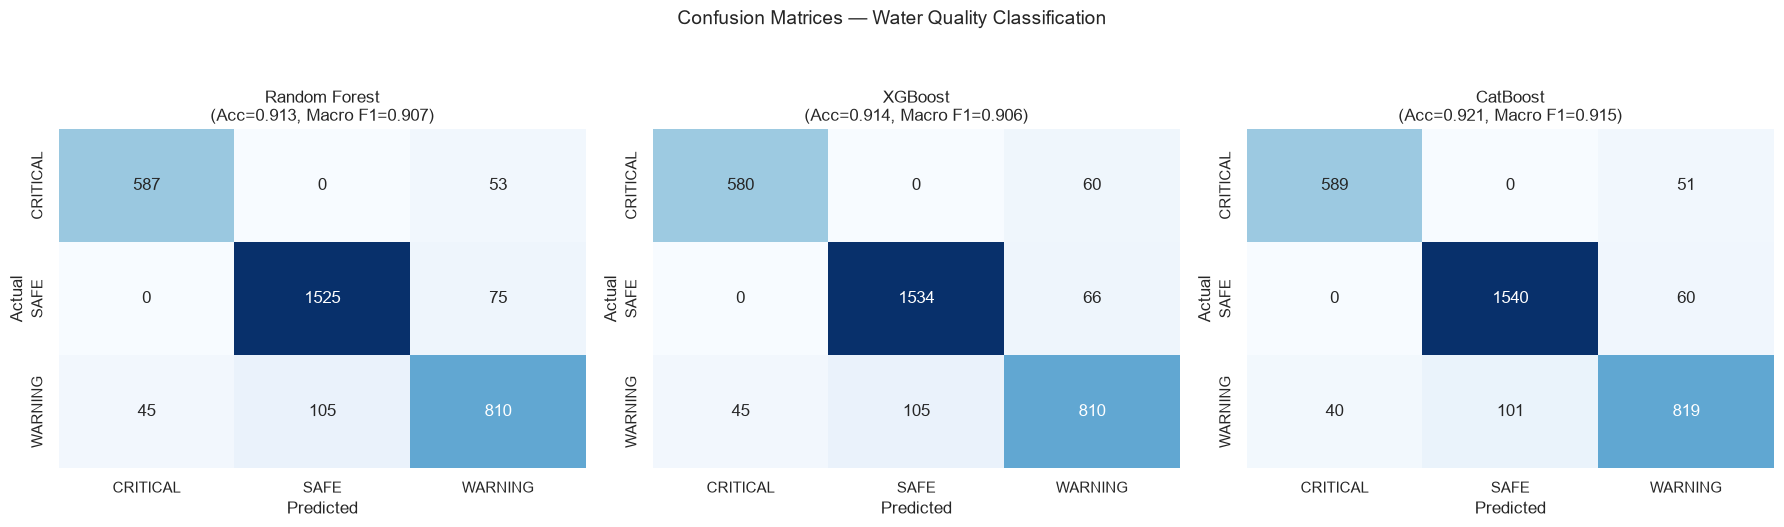

In [19]:
plot_confusion_matrices(water_quality_output)


Best Water Quality model (by Macro F1): CatBoost


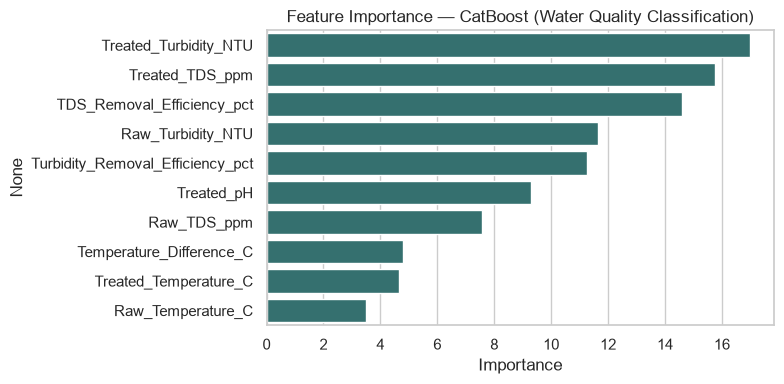

In [20]:
wq_best_name, wq_best = select_best_model(water_quality_output)
print(f"Best Water Quality model (by Macro F1): {wq_best_name}")
plot_feature_importance(water_quality_output, wq_best_name)


## 10. Save Best Models, Feature Lists, and Metrics



In [21]:
# ---- Save best models ----
joblib.dump(fh_best["model"], "models/filter_health_best_model.joblib")
joblib.dump(water_quality_output["results"][wq_best_name]["model"], "models/water_quality_best_model.joblib")

# ---- Save label encoders (needed to decode predictions back to class names) ----
joblib.dump(filter_health_output["label_encoder"], "models/filter_health_label_encoder.joblib")
joblib.dump(water_quality_output["label_encoder"], "models/water_quality_label_encoder.joblib")

# ---- Save the exact feature lists each model expects ----
feature_lists = {
    "filter_health_features": FILTER_HEALTH_FEATURES,
    "water_quality_features": WATER_QUALITY_FEATURES,
}
with open("models/feature_lists.json", "w") as f:
    json.dump(feature_lists, f, indent=2)

# ---- Save metrics summary ----
metrics_summary = {
    "filter_health": {
        "best_model": fh_best_name,
        "comparison_table": fh_comparison_table.to_dict(orient="records"),
    },
    "water_quality": {
        "best_model": wq_best_name,
        "comparison_table": wq_comparison_table.to_dict(orient="records"),
    },
}
with open("outputs/metrics_summary.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)

fh_comparison_table.to_csv("outputs/filter_health_model_comparison.csv", index=False)
wq_comparison_table.to_csv("outputs/water_quality_model_comparison.csv", index=False)

print("Saved:")
print(" - models/filter_health_best_model.joblib")
print(" - models/water_quality_best_model.joblib")
print(" - models/filter_health_label_encoder.joblib")
print(" - models/water_quality_label_encoder.joblib")
print(" - models/feature_lists.json")
print(" - outputs/metrics_summary.json")
print(" - outputs/filter_health_model_comparison.csv")
print(" - outputs/water_quality_model_comparison.csv")


Saved:
 - models/filter_health_best_model.joblib
 - models/water_quality_best_model.joblib
 - models/filter_health_label_encoder.joblib
 - models/water_quality_label_encoder.joblib
 - models/feature_lists.json
 - outputs/metrics_summary.json
 - outputs/filter_health_model_comparison.csv
 - outputs/water_quality_model_comparison.csv


## 11. Prediction Function — for a New ESP32 / Backend Reading



In [22]:
def load_inference_artifacts(models_dir="models"):
    return {
        "filter_health_model": joblib.load(f"{models_dir}/filter_health_best_model.joblib"),
        "filter_health_encoder": joblib.load(f"{models_dir}/filter_health_label_encoder.joblib"),
        "water_quality_model": joblib.load(f"{models_dir}/water_quality_best_model.joblib"),
        "water_quality_encoder": joblib.load(f"{models_dir}/water_quality_label_encoder.joblib"),
        "feature_lists": json.load(open(f"{models_dir}/feature_lists.json")),
    }


def predict_filter_health(reading: dict, artifacts: dict):
    """
    reading: dict containing at least the 18 Filter Health features, e.g.
        {
            "Raw_TDS_ppm": ..., "Raw_Turbidity_NTU": ..., "Raw_Temperature_C": ...,
            "Treated_TDS_ppm": ..., "Treated_Turbidity_NTU": ..., "Treated_pH": ...,
            "Treated_Temperature_C": ..., "Flow_Rate_L_min": ...,
            "TDS_Removal_Efficiency_pct": ..., "Turbidity_Removal_Efficiency_pct": ...,
            "Temperature_Difference_C": ..., "Previous_TDS_Efficiency_pct": ...,
            "Efficiency_Improvement_pp": ..., "Rolling_3Cycle_Avg_Efficiency_pct": ...,
            "Efficiency_Trend_pct": ..., "Previous_Turbidity_Efficiency_pct": ...,
            "Rolling_3Cycle_Avg_Turbidity_Efficiency_pct": ..., "Cycle_Number": ...,
        }
    """
    feats = artifacts["feature_lists"]["filter_health_features"]
    x = pd.DataFrame([{f: reading[f] for f in feats}])

    model = artifacts["filter_health_model"]
    encoder = artifacts["filter_health_encoder"]

    pred_idx = model.predict(x)
    pred_idx = int(np.array(pred_idx).ravel()[0])
    pred_label = encoder.inverse_transform([pred_idx])[0]

    proba = model.predict_proba(x)[0]
    proba_dict = {cls: float(p) for cls, p in zip(encoder.classes_, proba)}

    return {
        "predicted_class": pred_label,
        "confidence": float(max(proba)),
        "class_probabilities": proba_dict,
    }


def predict_water_quality(reading: dict, artifacts: dict):
    """
    reading: dict containing at least the 10 Water Quality features
    (Raw_TDS_ppm, Raw_Turbidity_NTU, Raw_Temperature_C, Treated_TDS_ppm,
     Treated_Turbidity_NTU, Treated_pH, Treated_Temperature_C,
     TDS_Removal_Efficiency_pct, Turbidity_Removal_Efficiency_pct, Temperature_Difference_C)
    """
    feats = artifacts["feature_lists"]["water_quality_features"]
    x = pd.DataFrame([{f: reading[f] for f in feats}])

    model = artifacts["water_quality_model"]
    encoder = artifacts["water_quality_encoder"]

    pred_idx = model.predict(x)
    pred_idx = int(np.array(pred_idx).ravel()[0])
    pred_label = encoder.inverse_transform([pred_idx])[0]

    proba = model.predict_proba(x)[0]
    proba_dict = {cls: float(p) for cls, p in zip(encoder.classes_, proba)}

    return {
        "predicted_class": pred_label,
        "confidence": float(max(proba)),
        "class_probabilities": proba_dict,
    }


In [23]:
# ---- Example usage with a real test-set row (sanity check) ----
artifacts = load_inference_artifacts()

sample_row = test_df.iloc[0]
sample_reading = sample_row[FILTER_HEALTH_FEATURES].to_dict()

fh_prediction = predict_filter_health(sample_reading, artifacts)
print("Filter Health prediction for test_df row 0:")
print(fh_prediction)
print("Actual label:", sample_row["Filter_Health"])

wq_reading = sample_row[WATER_QUALITY_FEATURES].to_dict()
wq_prediction = predict_water_quality(wq_reading, artifacts)
print("\nWater Quality prediction for test_df row 0:")
print(wq_prediction)
print("Actual label:", sample_row["Water_Quality_Class"])


Filter Health prediction for test_df row 0:
{'predicted_class': 'HEALTHY', 'confidence': 0.8471306160206011, 'class_probabilities': {'HEALTHY': 0.8471306160206011, 'MODERATE': 0.15155091968207762, 'UNHEALTHY': 0.0013184642973212363}}
Actual label: HEALTHY

Water Quality prediction for test_df row 0:
{'predicted_class': 'SAFE', 'confidence': 0.9707480669334878, 'class_probabilities': {'CRITICAL': 0.0015601779534992087, 'SAFE': 0.9707480669334878, 'WARNING': 0.027691755113013018}}
Actual label: SAFE


## 12. Final Summary & Analysis



In [24]:
print("="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\n[Filter Health] Best model: {fh_best_name}")
print(fh_comparison_table.to_string(index=False))

print(f"\n[Water Quality] Best model: {wq_best_name}")
print(wq_comparison_table.to_string(index=False))

print("""
--- Feature Importance ---
See Section 8/9 plots for the actual ranked importances from the trained models —
do not assume in advance which features dominate; report what the model found.

--- Data Leakage Check ---
- Filter_Health_Score_pct was excluded from Filter Health features (verified by assertion in Section 4).
- Sample_ID, Water_Quality_Class, Filter_Health, ML_Split were excluded from both feature lists (verified by assertion in Section 4).
- Any model reporting >=99.5% accuracy was flagged above; if that occurs, re-check the
  feature list and the label-generation logic of the synthetic dataset before trusting the result,
  since very high accuracy on synthetic data commonly reflects easy separability rather than
  leakage. It's worth reviewing whichever training script generated the synthetic labels to
  confirm classes weren't produced from a simple threshold on one of the input features.

--- Integration Into FastAPI Backend ---
1. Copy 'models/filter_health_best_model.joblib', 'models/water_quality_best_model.joblib',
   the two label-encoder .joblib files, and 'models/feature_lists.json' into the backend's
   model directory (e.g. app/ml_models/).
2. At startup, load them once (as in load_inference_artifacts()) rather than per-request.
3. After the existing cycle-aggregation / efficiency-calculation step produces a feature
   dict for a cycle, call predict_filter_health() and predict_water_quality() with that dict.
4. Return predicted_class + confidence alongside the existing rule-based
   OPTIMIZE / CONTINUE / HOLD / NO_ACTION decision — keep the ML output as a separate field,
   not a replacement for the decision engine.
5. Log every prediction (features + prediction + confidence) so real prototype readings
   can later be compared against these synthetic-data-trained models.

--- What Must Be Validated on Real Hardware ---
- This dataset is synthetic (8,000 generated rows), not real field or lab data.
- Before trusting these models operationally: collect real ESP32/JAL-RAKSHAK cycle readings,
  label them (engineering score + manual/lab verification where possible), and evaluate the
  saved models on that real data.
- Watch for distribution shift: real sensor noise, drift, and correlations between features
  may differ from the synthetic generator's assumptions (Qmax=2 L/min, Eturb_base=80%, etc.).
- Only after real-world validation should predicted classes be used to influence alerts or
  treatment decisions.
""")


FINAL SUMMARY

[Filter Health] Best model: CatBoost
        Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Precision (weighted)  Recall (weighted)  F1 (weighted)
     CatBoost    0.9372             0.9349          0.9292      0.9318                0.9367             0.9372         0.9367
Random Forest    0.9313             0.9273          0.9232      0.9252                0.9308             0.9313         0.9310
      XGBoost    0.9272             0.9239          0.9190      0.9213                0.9266             0.9272         0.9266

[Water Quality] Best model: CatBoost
        Model  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)  Precision (weighted)  Recall (weighted)  F1 (weighted)
     CatBoost    0.9213             0.9185          0.9120      0.9151                0.9207             0.9213         0.9208
Random Forest    0.9131             0.9093          0.9047      0.9069                0.9126             0.9131         0.9128
      XGBoost    0.91